In [ ]:
pip install imbalanced-learn

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# load dataset

df = pd.read_csv('/content/MFG10YearTerminationData.csv')


# data cleaning and data preprocessing
# Encode the target variable 'STATUS' into numerical values
le_y = LabelEncoder()
y = le_y.fit_transform(df['STATUS'])

date_cols = ['recorddate_key','birthdate_key', 'orighiredate_key']
for col in date_cols:
  df[col] = pd.to_datetime(df[col]).dt.year


# handling missing or error values
# for object based values

for col in df.columns:
   if df[col].dtype == "object":
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    obj_imputer = SimpleImputer(strategy = "most_frequent")

    df[col] = obj_imputer.fit_transform(df[col].to_numpy().reshape(-1, 1))
   elif df[col].dtype != 'object' and df[col].isnull().any(): # Corrected indentation for elif
    num_imputer = SimpleImputer(strategy = "mean")
    df[col] = num_imputer.fit_transform(df[col].to_numpy().reshape(-1, 1))

# scaling

scaler = StandardScaler()
X = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# oversampling

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y_train)

# Create x AFTER all preprocessing has been applied to df
x = df.drop(['EmployeeID','terminationdate_key','termreason_desc','termtype_desc','STATUS'], axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
print(f"""
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")


x_train : (39722, 13)
x_test : (9931, 13)
y_train : (39722,)
y_test : (9931,)



In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix )

xgb_model = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.1,
    max_depth = 5,
    random_state = 42,
    n_jobs = -1,
    colsample_bytree = 0.7,
    subsample = 0.8,
    eval_metric = 'logloss',
    objective = 'binary:logistic')

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred)
recall_scores = recall_score(y_test, y_pred)
f1_scores = f1_score(y_test, y_pred)

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores}
""")



Accuracy Score : 0.9940590071493304
Precision Score : 0.9915966386554622
Recall Score : 0.8054607508532423
F1 Score : 0.8888888888888888



              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9638
           1       0.99      0.81      0.89       293

    accuracy                           0.99      9931
   macro avg       0.99      0.90      0.94      9931
weighted avg       0.99      0.99      0.99      9931



<Figure size 800x800 with 0 Axes>

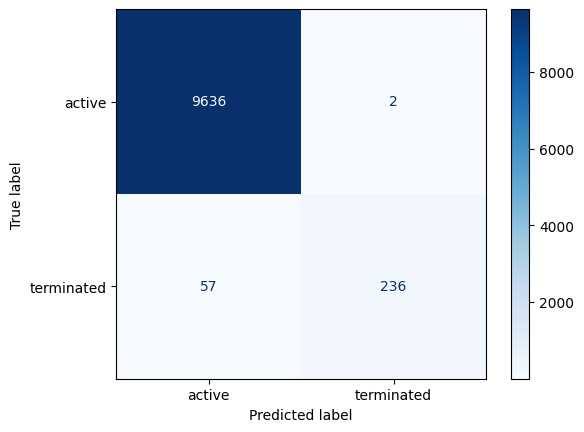

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

figure = plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['active', 'terminated'])
disp.plot(cmap='Blues')
plt.show()

In [33]:
import joblib
if joblib.dump(xgb_model, 'employee_atrribution.pkl'):
  print("model saved")

model saved
